# Exploratory Data Analysis
Xente transaction dataset for Bati Bank credit risk modeling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/data.csv')
print(df.shape)
df.head()

(95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

In [3]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [4]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

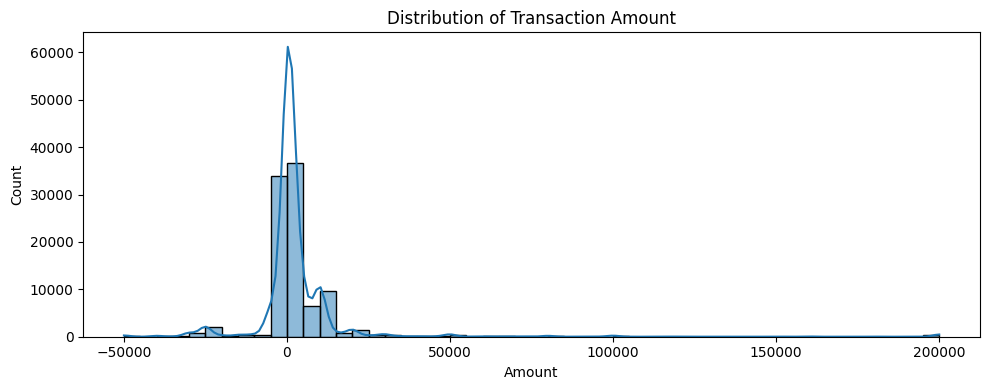

In [5]:
plt.figure(figsize=(10,4))
sns.histplot(df['Amount'].clip(-50000, 200000), bins=50, kde=True)
plt.title('Distribution of Transaction Amount')
plt.tight_layout()
plt.savefig('amount_dist.png')
plt.show()

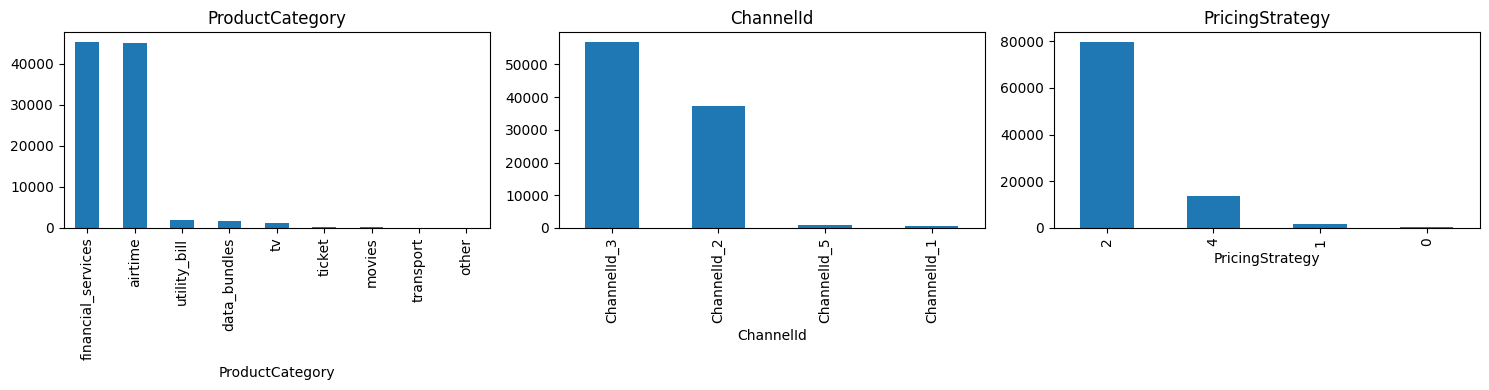

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['ProductCategory', 'ChannelId', 'PricingStrategy']):
    df[col].value_counts().plot(kind='bar', ax=ax, title=col)
plt.tight_layout()
plt.savefig('categorical_dist.png')
plt.show()

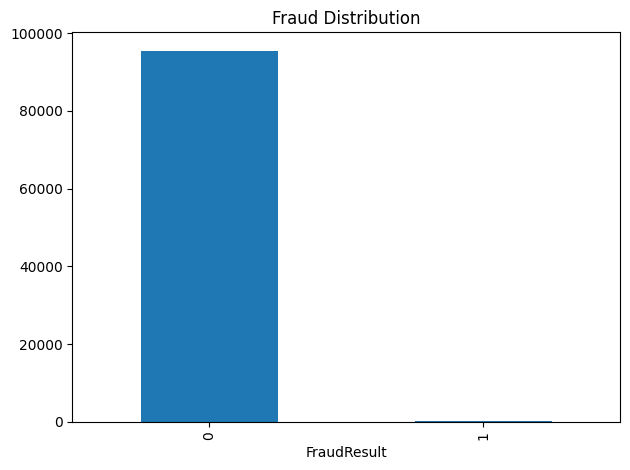

FraudResult
0    0.997982
1    0.002018
Name: proportion, dtype: float64


In [7]:
df['FraudResult'].value_counts().plot(kind='bar', title='Fraud Distribution')
plt.tight_layout()
plt.savefig('fraud_dist.png')
plt.show()
print(df['FraudResult'].value_counts(normalize=True))

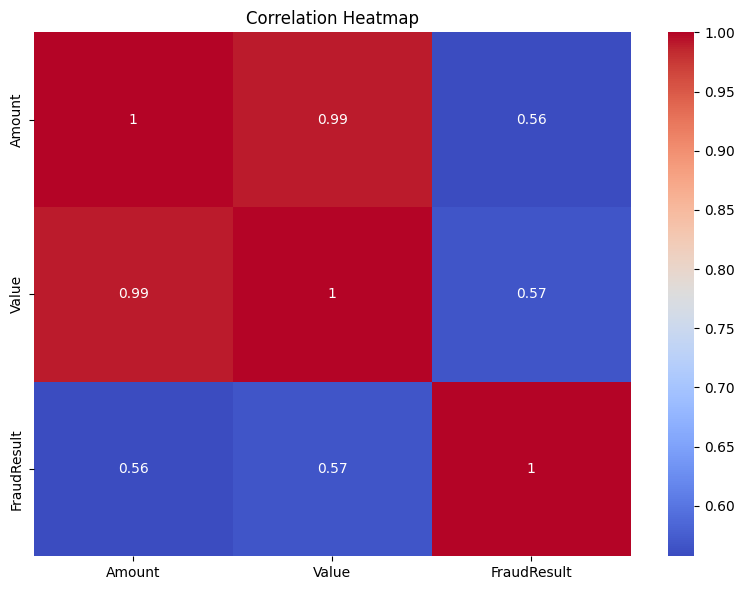

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Amount','Value','FraudResult']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation.png')
plt.show()

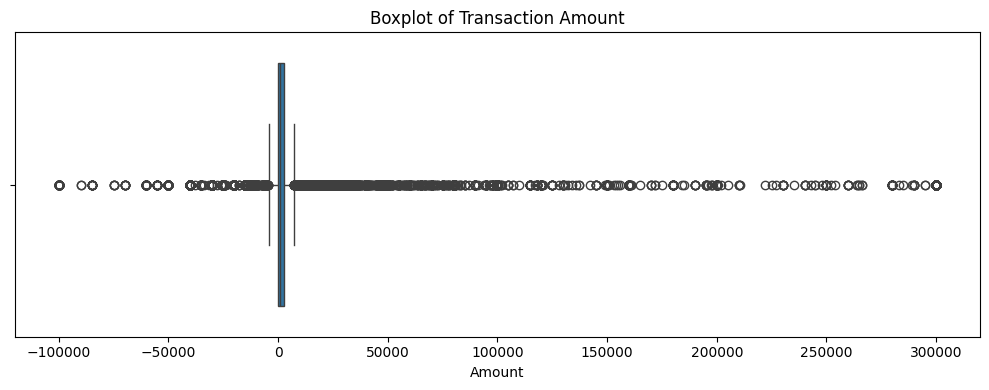

In [9]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['Amount'].clip(-100000, 300000))
plt.title('Boxplot of Transaction Amount')
plt.tight_layout()
plt.savefig('boxplot.png')
plt.show()

count    3742.000000
mean       25.564404
std        96.929602
min         1.000000
25%         2.000000
50%         7.000000
75%        20.000000
max      4091.000000
Name: TransactionId, dtype: float64


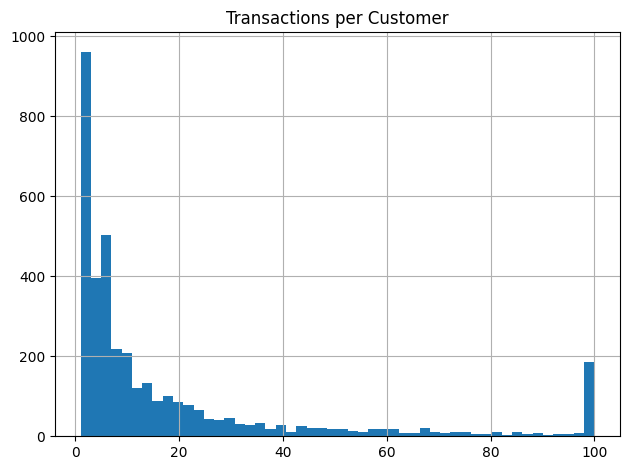

In [10]:
txn_per_customer = df.groupby('CustomerId')['TransactionId'].count()
print(txn_per_customer.describe())
txn_per_customer.clip(0, 100).hist(bins=50)
plt.title('Transactions per Customer')
plt.tight_layout()
plt.savefig('txn_per_customer.png')
plt.show()

## Key Insights

1. **Highly imbalanced fraud labels** - less than 2% of transactions are fraudulent.
2. **Amount has extreme outliers** - capping is necessary before modeling.
3. **Transaction frequency is skewed** - most customers have very few transactions.
4. **ProductCategory and ChannelId are concentrated** - a few categories dominate.
5. **Amount and Value are highly correlated** - Value is the absolute amount, multicollinearity risk.